# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend's prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [83]:
# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesado y partición
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# Árboles de decisión (regresión y clasificación)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [84]:
# Cargamos el dataset de temperaturas de Seattle
temps = pd.read_csv('data/temps.csv')
temps.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [85]:
# Vemos tipos de datos y valores nulos
temps.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


In [86]:
# Estadísticas básicas de las columnas numéricas
temps.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


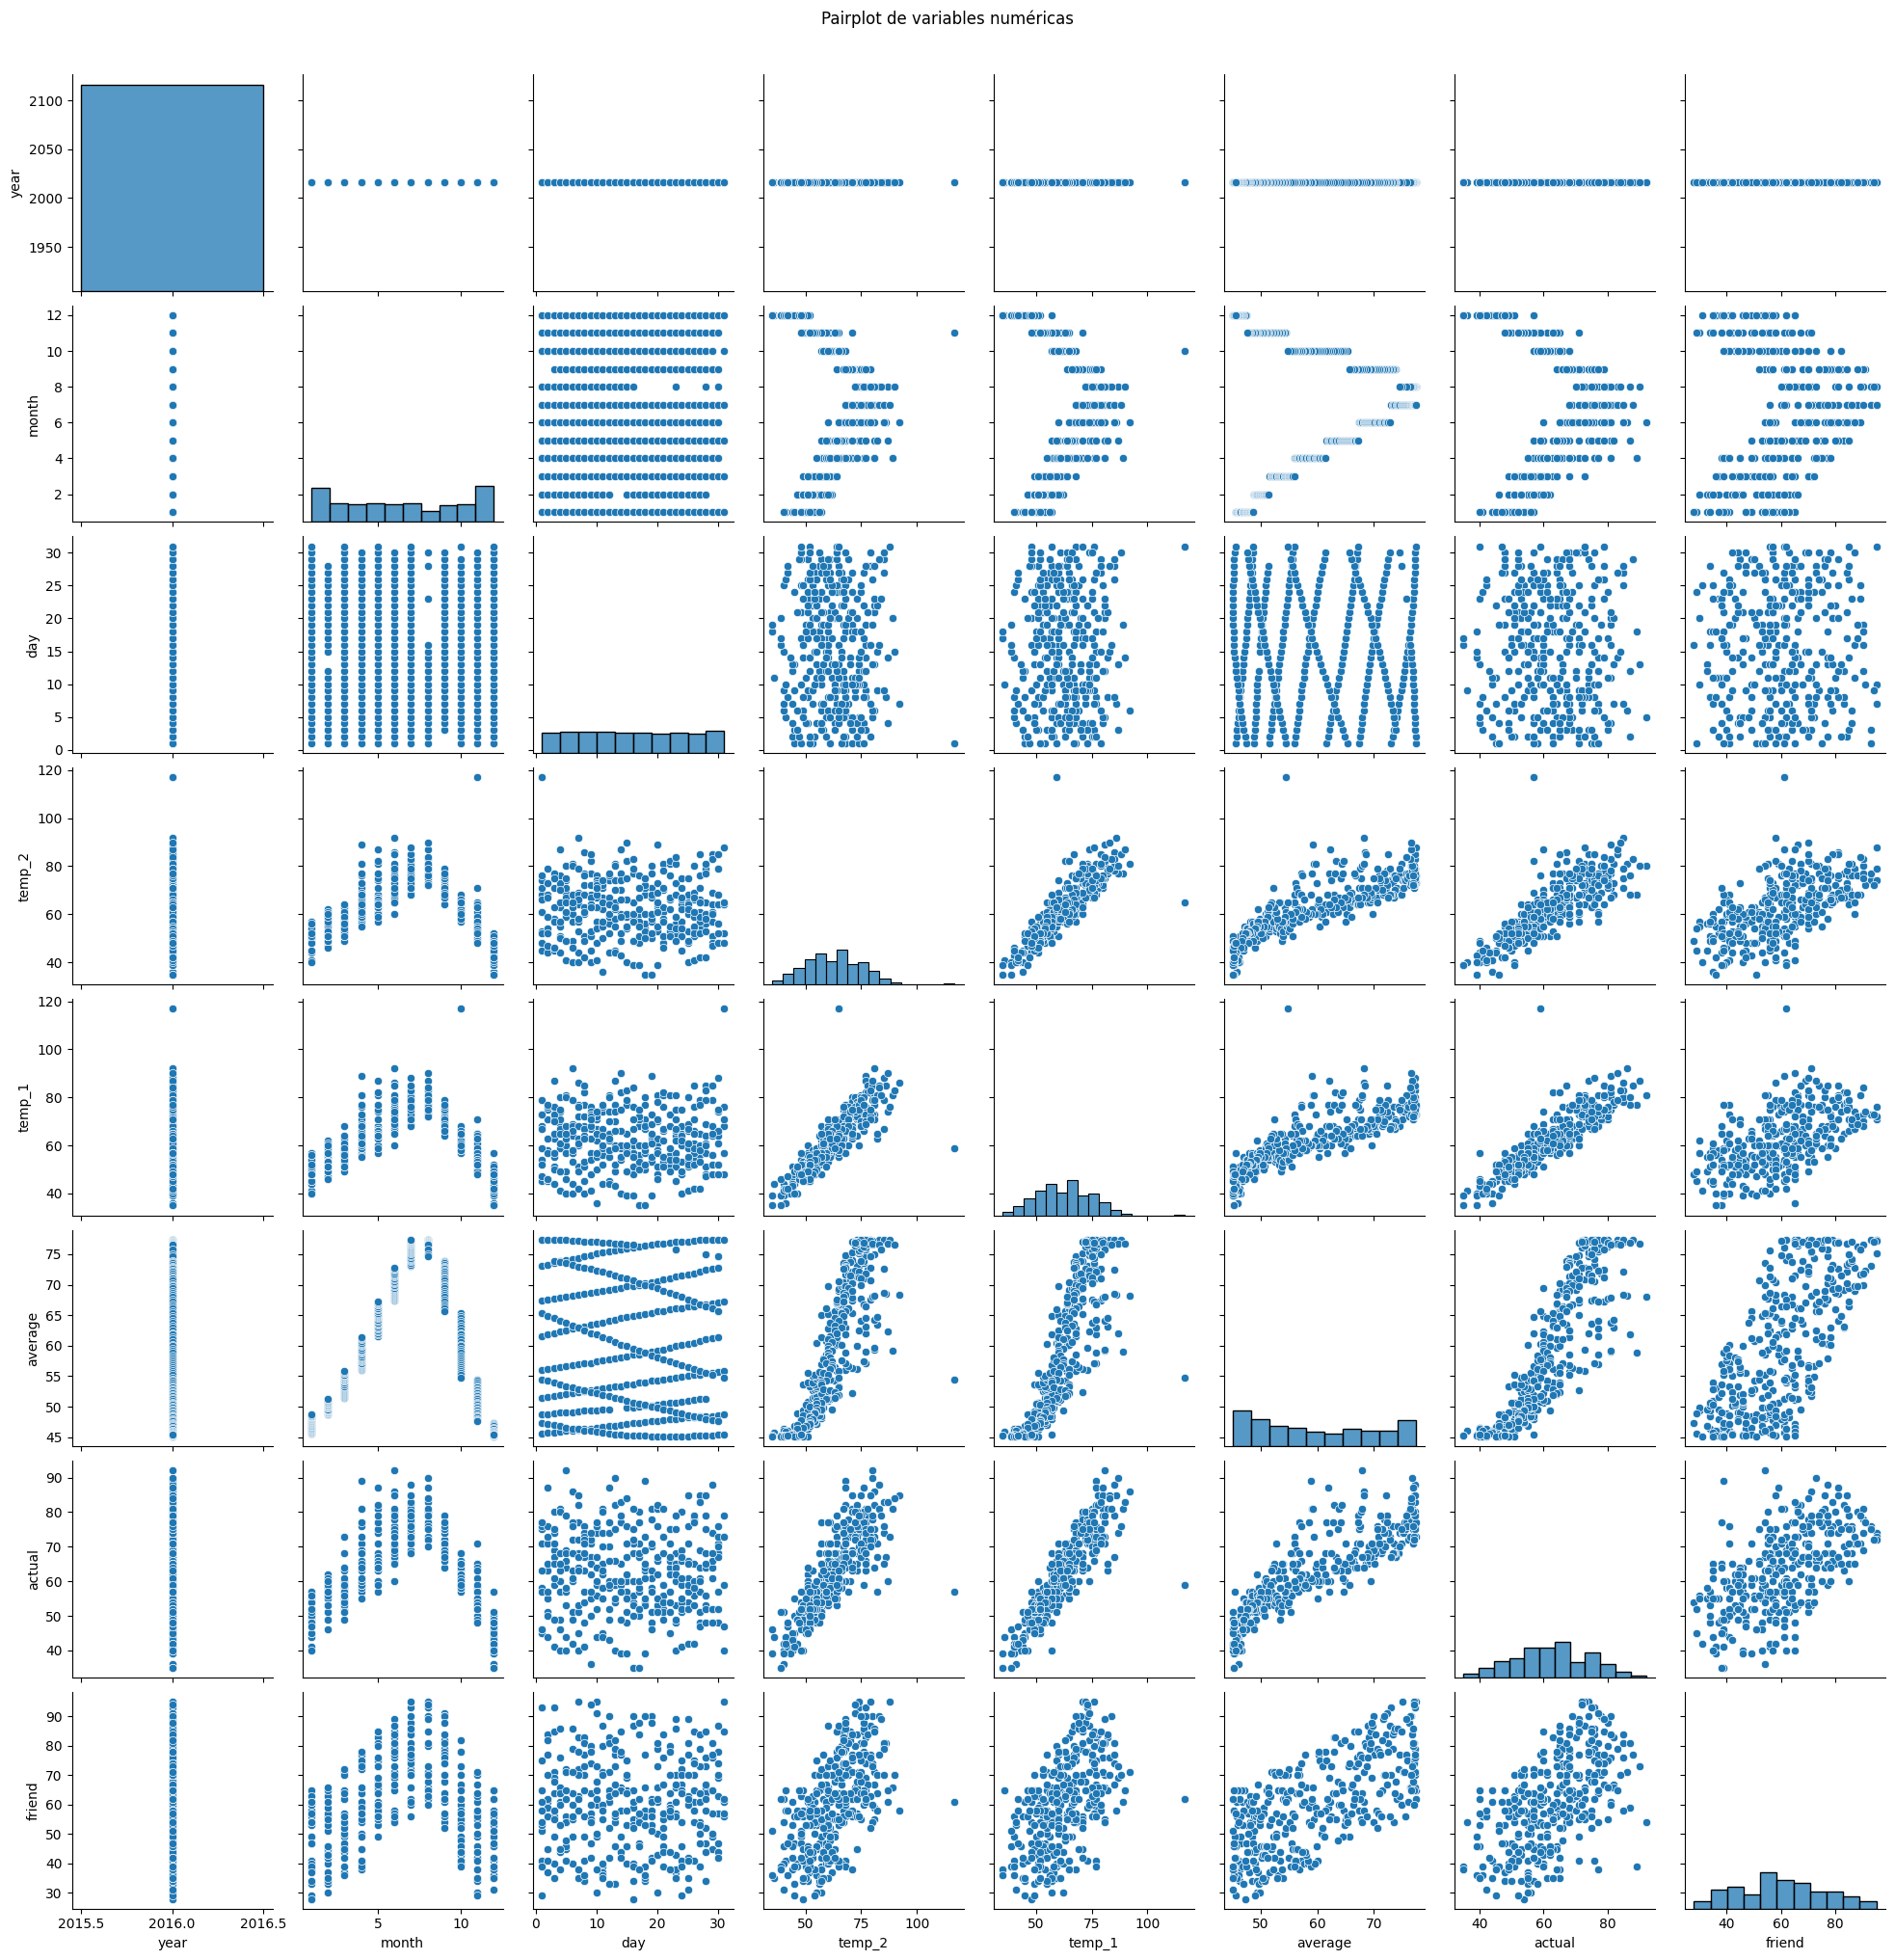

In [87]:
# Pairplot: vemos cómo se relacionan las variables entre sí
# Puede tardar unos segundos en generarse
sns.pairplot(temps.select_dtypes(include='number'))
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

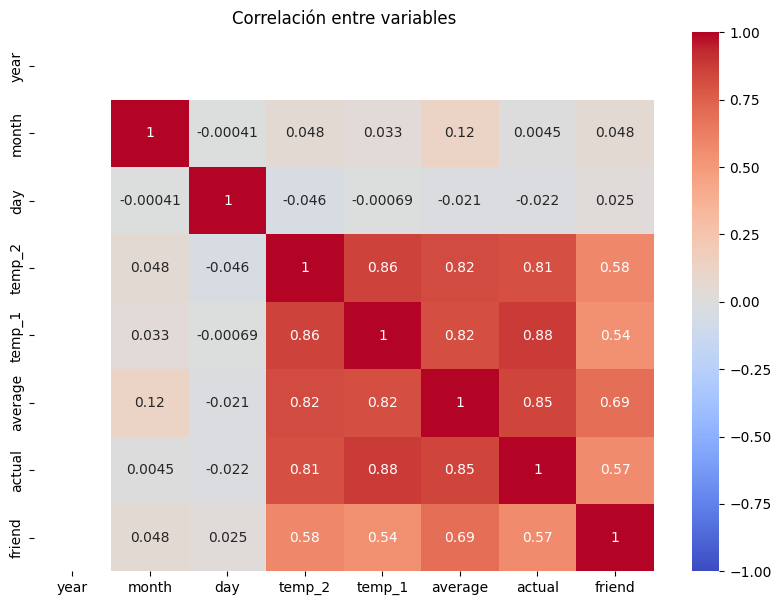

In [88]:
# Mapa de calor de correlaciones
# Cuanto más rojo → correlación positiva | más azul → correlación negativa
plt.figure(figsize=(10, 7))
sns.heatmap(temps.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables')
plt.show()

### 3. Selecciona variables y divide en train y test

In [89]:
# La columna 'week' es texto → necesitamos convertirla a número
# LabelEncoder le asigna un número entero a cada día de la semana
encoder = LabelEncoder()
temps['week_encoded'] = encoder.fit_transform(temps['week'])

temps.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_encoded
0,2016,1,1,Fri,45,45,45.6,45,29,0
1,2016,1,2,Sat,44,45,45.7,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,56,3
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,5


In [105]:
#IMPORTANTE: 'actual' es lo que queremos predecir (target).
#    Si la incluimos en X estaríamos haciendo trampa (data leakage).
#    Por eso la dejamos FUERA de feature_names.

feature_names = ['month', 'day',
                 'temp_2', 'temp_1', 'average',
                 'friend', 'week_encoded']

X = temps[feature_names]   # variables predictoras
y = temps['actual']        # variable objetivo (temperatura máxima real)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (348, 7)
Forma de y: (348,)


In [91]:
# Dividimos en entrenamiento (80%) y test (20%)
# random_state=42 → hace que la división sea siempre la misma (reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de test:          {X_test.shape[0]} filas")

Datos de entrenamiento: 278 filas
Datos de test:          70 filas


### 4. Entrena el modelo

> **Nota**: Usamos `DecisionTreeRegressor` porque el objetivo es predecir un valor numérico continuo (temperatura).  
> `DecisionTreeClassifier` se usa cuando queremos predecir una categoría (ej: frío/calor), que haremos en el paso 12.

In [92]:
# Creamos el árbol de regresión con profundidad máxima 2
# max_depth=2 → el árbol tendrá como máximo 2 niveles de decisión
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
tree_reg.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 5. Evaluación del modelo
Calculamos las métricas sobre el conjunto de test.

In [93]:
# Generamos predicciones sobre los datos de test
predictions = tree_reg.predict(X_test)

print(f"  MAE  (Error Absoluto Medio):       {mean_absolute_error(y_test, predictions):.3f} °F")
print(f"  MAPE (Error % Absoluto Medio):     {mean_absolute_percentage_error(y_test, predictions)*100:.2f} %")
print(f"  MSE  (Error Cuadrático Medio):     {mean_squared_error(y_test, predictions):.3f}")
print(f"  RMSE (Raíz del MSE):               {np.sqrt(mean_squared_error(y_test, predictions)):.3f} °F")
print(f"  R2 en entrenamiento: {tree_reg.score(X_train, y_train):.4f}")
print(f"  R2 en test:          {tree_reg.score(X_test, y_test):.4f}")

  MAE  (Error Absoluto Medio):       4.889 °F
  MAPE (Error % Absoluto Medio):     7.74 %
  MSE  (Error Cuadrático Medio):     37.648
  RMSE (Raíz del MSE):               6.136 °F
  R2 en entrenamiento: 0.7929
  R2 en test:          0.7308


### 6. Representa el árbol de decisión

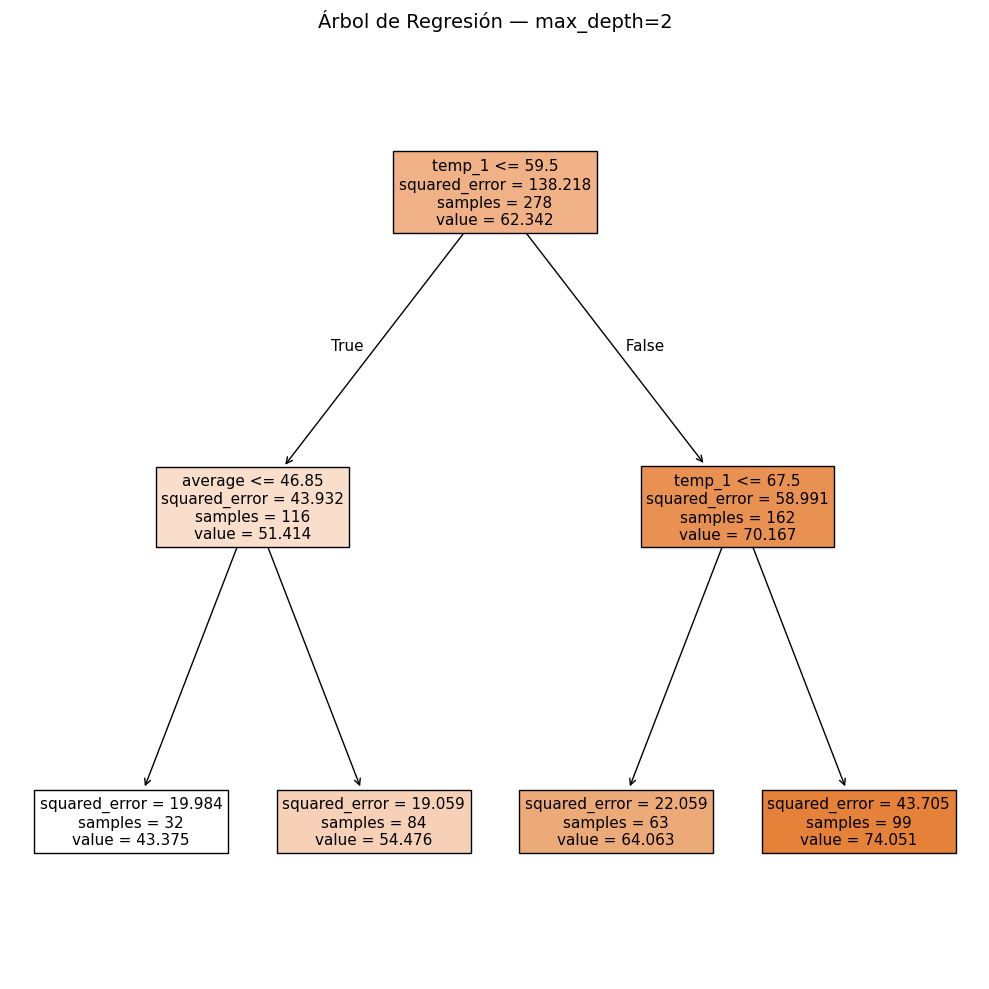

In [94]:
# Visualizamos la estructura del árbol
# Cada nodo muestra: la condición de división, el error y el número de muestras
plt.figure(figsize=(10, 10))
plot_tree(
    tree_reg,
    feature_names=feature_names,
    filled=True,          
    fontsize=11
)
plt.title("Árbol de Regresión — max_depth=2", fontsize=14)
plt.tight_layout()
plt.show()

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [95]:
# Creamos y entrenamos el árbol con profundidad 3
# Al tener un nivel más, el modelo es más complejo y puede capturar más patrones
tree_reg3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg3.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [96]:
predictions3 = tree_reg3.predict(X_test)

print(f"  MAE:  {mean_absolute_error(y_test, predictions3):.3f} °F")
print(f"  MAPE: {mean_absolute_percentage_error(y_test, predictions3)*100:.2f} %")
print(f"  MSE:  {mean_squared_error(y_test, predictions3):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, predictions3)):.3f} °F")
print(f"  R2 entrenamiento: {tree_reg3.score(X_train, y_train):.4f}")
print(f"  R2 test:          {tree_reg3.score(X_test, y_test):.4f}")


  MAE:  4.267 °F
  MAPE: 6.74 %
  MSE:  30.946
  RMSE: 5.563 °F
  R2 entrenamiento: 0.8397
  R2 test:          0.7787


### 9. Vuelve a representar su árbol

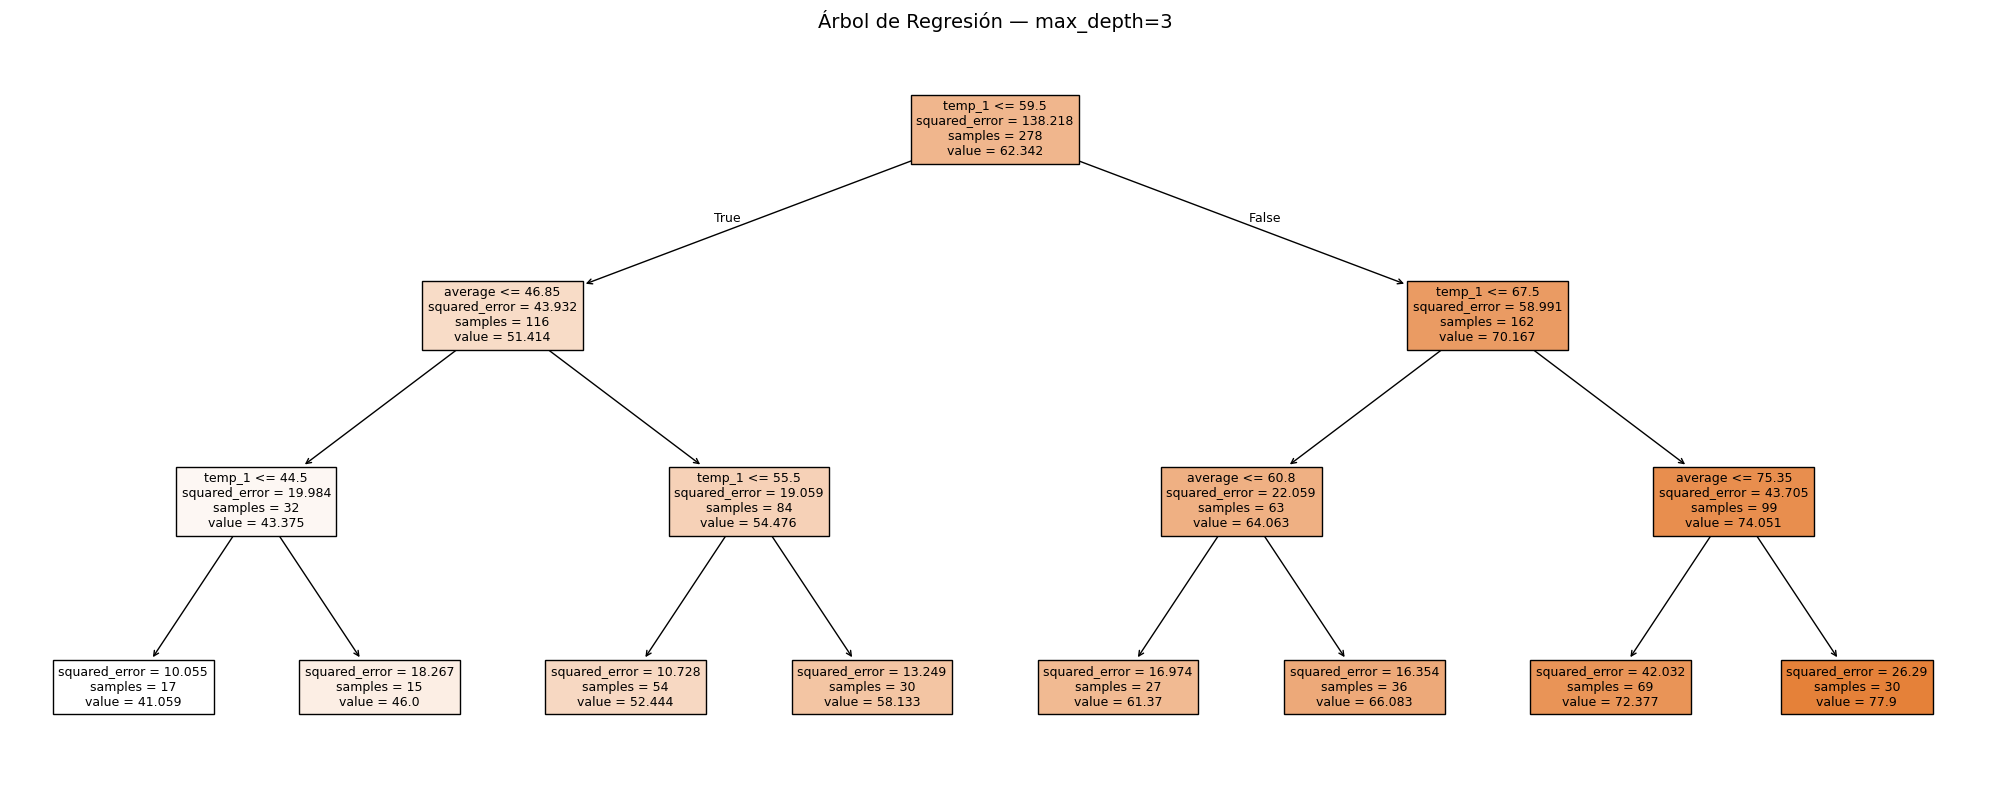

In [97]:
plt.figure(figsize=(20, 8))
plot_tree(
    tree_reg3,
    feature_names=feature_names,
    filled=True,
    fontsize=9
    )
plt.title("Árbol de Regresión — max_depth=3", fontsize=14)
plt.tight_layout()
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [98]:
# Definimos los hiperparámetros que queremos probar
param_grid = {
    'max_depth'        : [2, 3, 4, 5, None],  # None = sin límite de profundidad
    'min_samples_split': [2, 5, 10],           # mínimo de muestras para dividir un nodo
    'min_samples_leaf' : [1, 2, 4]             # mínimo de muestras en una hoja
}

# GridSearchCV prueba todas las combinaciones con 5-fold cross validation
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5 particiones para la validación cruzada
    scoring='r2',       # optimizamos por R²
    n_jobs=-1           # usa todos los núcleos del procesador
)

grid_search.fit(X_train, y_train)

print(f"   Mejores hiperparámetros: {grid_search.best_params_}")
print(f"   Mejor R² (cv):           {grid_search.best_score_:.4f}")

   Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Mejor R² (cv):           0.7735


In [99]:
# Evaluamos el mejor modelo encontrado sobre el test
best_tree = grid_search.best_estimator_
best_preds = best_tree.predict(X_test)

print("Grid Search")
print(f"  MAE:  {mean_absolute_error(y_test, best_preds):.3f} °F")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, best_preds)):.3f} °F")
print(f"  R² test: {r2_score(y_test, best_preds):.4f}")

Grid Search
  MAE:  4.267 °F
  RMSE: 5.563 °F
  R² test: 0.7787


### 11. Obten el `feature_importances` de cada variable en el último modelo

🔍 Importancia de cada variable:
temp_1          0.8811
average         0.1189
month           0.0000
temp_2          0.0000
day             0.0000
friend          0.0000
week_encoded    0.0000
dtype: float64


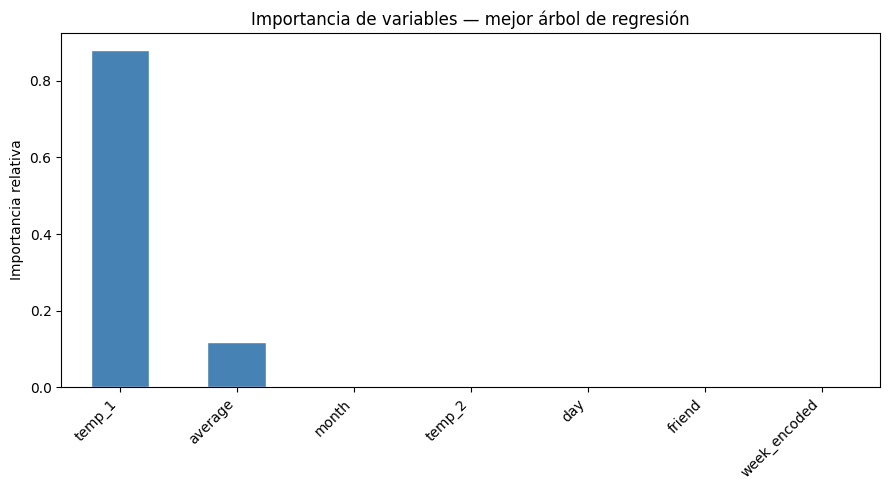

In [100]:
# feature_importances_ indica qué porcentaje de la 'utilidad' total aporta cada variable
importances = pd.Series(
    best_tree.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("🔍 Importancia de cada variable:")
print(importances.round(4))

# Gráfico de barras de importancias
plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia de variables — mejor árbol de regresión')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [101]:
# Creamos la variable objetivo binaria
# temps['actual'] > 59 devuelve True/False → lo convertimos a 1/0 con astype(int)
y_class = (temps['actual'] > 59).astype(int)

print(f"Días con temp > 59°F (>15°C): {y_class.sum()}  ({y_class.mean()*100:.1f}%)")
print(f"Días con temp ≤ 59°F (≤15°C): {(y_class==0).sum()} ({(1-y_class.mean())*100:.1f}%)")

Días con temp > 59°F (>15°C): 204  (58.6%)
Días con temp ≤ 59°F (≤15°C): 144 (41.4%)


In [102]:
# Usamos las mismas features que antes
X_cls = temps[feature_names]

# División train/test
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_class,
    test_size=0.2,
    random_state=42
)

# Grid Search para el árbol de clasificación
param_grid_cls = {
    'max_depth'        : [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

grid_cls = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_cls,
    cv=5,
    scoring='accuracy',   # en clasificación optimizamos por exactitud (% de aciertos)
    n_jobs=-1
)

grid_cls.fit(X_cls_train, y_cls_train)

print(f"   Mejores hiperparámetros: {grid_cls.best_params_}")
print(f"   Mejor accuracy (cv):     {grid_cls.best_score_*100:.2f}%")

   Mejores hiperparámetros: {'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
   Mejor accuracy (cv):     88.86%


🎯 Accuracy en test: 85.71%

📋 Informe de clasificación:
                precision    recall  f1-score   support

  ≤59°F (frío)       0.82      0.82      0.82        28
>59°F (cálido)       0.88      0.88      0.88        42

      accuracy                           0.86        70
     macro avg       0.85      0.85      0.85        70
  weighted avg       0.86      0.86      0.86        70



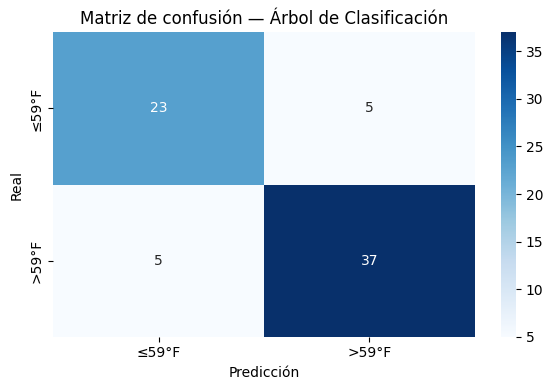

In [103]:
# Evaluación del mejor clasificador
best_clf = grid_cls.best_estimator_
y_cls_pred = best_clf.predict(X_cls_test)

print(f"🎯 Accuracy en test: {accuracy_score(y_cls_test, y_cls_pred)*100:.2f}%")
print()
print("📋 Informe de clasificación:")
print(classification_report(y_cls_test, y_cls_pred, target_names=['≤59°F (frío)', '>59°F (cálido)']))

# Matriz de confusión
cm = confusion_matrix(y_cls_test, y_cls_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['≤59°F', '>59°F'],
            yticklabels=['≤59°F', '>59°F'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión — Árbol de Clasificación')
plt.tight_layout()
plt.show()

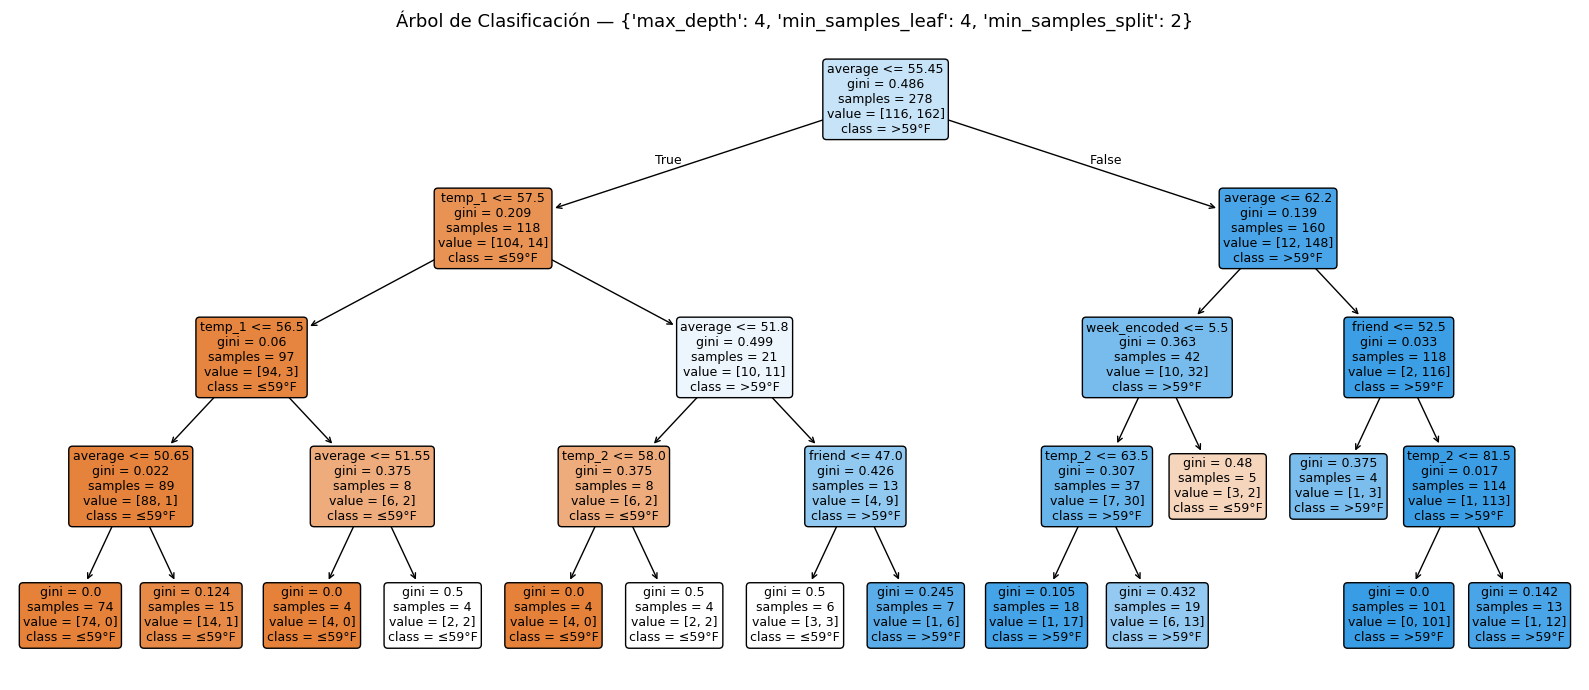

In [104]:
# Visualizamos el árbol de clasificación final
plt.figure(figsize=(16, 7))
plot_tree(
    best_clf,
    feature_names=feature_names,
    class_names=['≤59°F', '>59°F'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f"Árbol de Clasificación — {grid_cls.best_params_}", fontsize=13)
plt.tight_layout()
plt.show()